# Exploratory Analysis

## Objective

Use the cleaned and engineered Garmin running dataset to identify
training-volume, intensity, efficiency, and terrain patterns. The
analysis prioritizes clear questions and interpretable visuals rather
than building a dashboard or predictive model.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.cleaning import clean_garmin_activities
from src.features import (
    add_mvp_run_features,
    summarize_weekly_training,
)

In [2]:
COLORS = {
    "blue": "#2563EB",
    "pink": "#DB2777",
    "yellow": "#E5A000",
    "navy": "#172554",
    "background": "#F8FAFC",
    "grid": "#DCE3EC",
}

sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette=[
        COLORS["blue"],
        COLORS["pink"],
        COLORS["yellow"],
    ],
    rc={
        "figure.facecolor": COLORS["background"],
        "axes.facecolor": COLORS["background"],
        "axes.edgecolor": COLORS["navy"],
        "axes.labelcolor": COLORS["navy"],
        "axes.titlecolor": COLORS["navy"],
        "text.color": COLORS["navy"],
        "grid.color": COLORS["grid"],
        "xtick.color": COLORS["navy"],
        "ytick.color": COLORS["navy"],
    },
)

In [3]:
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "run_data.csv"
)

raw_activities = pd.read_csv(DATA_PATH)

runs = clean_garmin_activities(
    raw_activities
)

featured_runs = add_mvp_run_features(
    runs
)

weekly_training = summarize_weekly_training(
    featured_runs
)

print("Activities:", len(featured_runs))
print("Training weeks:", len(weekly_training))

Activities: 169
Training weeks: 55


In [4]:
featured_runs.head()

,Activity Type,Date,Favorite,Title,Distance,Calories,Time,Avg HR,Max HR,Aerobic TE,...,calendar_year,calendar_week,month,day_of_week,days_since_previous_run,rolling_7_day_distance_km,rolling_28_day_distance_km,metres_per_heartbeat,power_to_hr_ratio,speed_to_power_ratio
0,Running,2025-06-14 07:40:11,False,Hyrox eve run,4.0,247,0 days 00:25:29,148,169,3.1,...,2025,24,6,Saturday,<NA>,4.00,4.00,1.082524,1.878378,0.034578
1,Running,2025-06-17 10:25:09,False,Toronto Running,1.01,64,0 days 00:06:08.200000,149,162,2.0,...,2025,25,6,Tuesday,3,5.01,5.01,1.108205,1.704698,0.039005
2,Running,2025-06-19 11:06:18,False,Paris Running,1.0,61,0 days 00:05:02.200000,172,185,2.0,...,2025,25,6,Thursday,2,6.01,6.01,1.174536,2.116279,0.0333
3,Treadmill Running,2025-06-20 10:49:02,False,Treadmill Running,1.75,125,0 days 00:11:20,158,185,2.4,...,2025,25,6,Friday,1,7.76,7.76,2.792256,1.063291,0.157563
4,Running,2025-06-22 10:19:23,False,Paris Running,13.0,827,0 days 01:06:53,178,194,5.0,...,2025,25,6,Sunday,2,16.76,20.76,1.097976,1.578652,0.041731


In [5]:
weekly_training.head()

,week_start,weekly_distance_km,weekly_running_minutes,weekly_run_count
0,2025-06-09,4.0,24.966667,1
1,2025-06-16,16.76,81.550000,4
2,2025-06-23,8.94,45.881667,3
3,2025-06-30,26.01,140.416667,2
4,2025-07-07,25.02,131.766667,2


## 1. How has weekly training volume changed?

This section examines weekly running distance, moving time, and
frequency. Weeks are defined as Monday through Sunday. Weeks without
runs are not currently inserted, and the first and final weeks may
represent partial weeks.

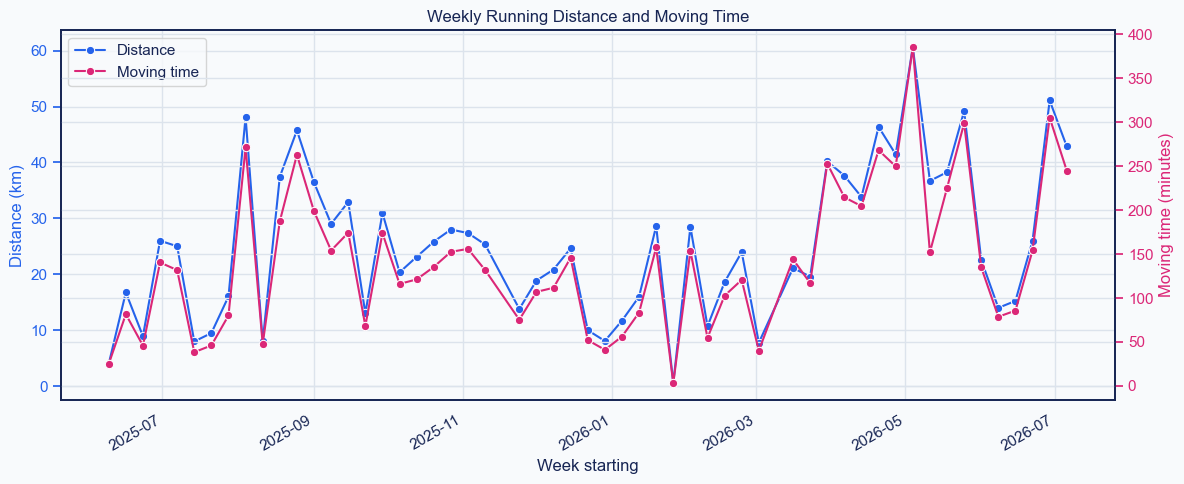

In [6]:
fig, distance_axis = plt.subplots(
    figsize=(12, 5),
)

time_axis = distance_axis.twinx()

distance_line = sns.lineplot(
    data=weekly_training,
    x="week_start",
    y="weekly_distance_km",
    marker="o",
    color=COLORS["blue"],
    label="Distance",
    ax=distance_axis,
)

time_line = sns.lineplot(
    data=weekly_training,
    x="week_start",
    y="weekly_running_minutes",
    marker="o",
    color=COLORS["pink"],
    label="Moving time",
    ax=time_axis,
)

distance_axis.set_title(
    "Weekly Running Distance and Moving Time"
)

distance_axis.set_xlabel(
    "Week starting"
)

distance_axis.set_ylabel(
    "Distance (km)",
    color=COLORS["blue"],
)

time_axis.set_ylabel(
    "Moving time (minutes)",
    color=COLORS["pink"],
)

distance_axis.tick_params(
    axis="y",
    colors=COLORS["blue"],
)

time_axis.tick_params(
    axis="y",
    colors=COLORS["pink"],
)

# Combine both axes into one legend.
distance_handles, distance_labels = (
    distance_axis.get_legend_handles_labels()
)

time_handles, time_labels = (
    time_axis.get_legend_handles_labels()
)

distance_axis.legend(
    distance_handles + time_handles,
    distance_labels + time_labels,
    loc="upper left",
)

# Remove the duplicate legend created on the second axis.
time_axis.get_legend().remove()

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

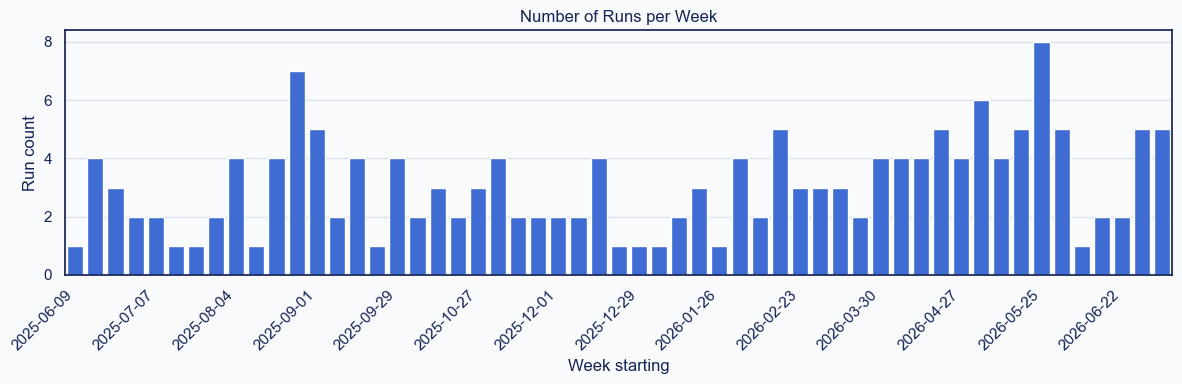

In [7]:
plt.figure(figsize=(12, 4))

sns.barplot(
    data=weekly_training,
    x="week_start",
    y="weekly_run_count",
    color=COLORS["blue"],
)

plt.title("Number of Runs per Week")
plt.xlabel("Week starting")
plt.ylabel("Run count")
plt.xticks(
    ticks=range(
        0,
        len(weekly_training),
        4,
    ),
    labels=weekly_training[
        "week_start"
    ].dt.strftime("%Y-%m-%d").iloc[::4],
    rotation=45,
    ha="right",
)

plt.tight_layout()
plt.show()

In [8]:
weekly_training.nlargest(
    5,
    "weekly_distance_km",
)[
    [
        "week_start",
        "weekly_distance_km",
        "weekly_running_minutes",
        "weekly_run_count",
    ]
]

,week_start,weekly_distance_km,weekly_running_minutes,weekly_run_count
45,2026-05-04,60.61,385.233333,6
53,2026-06-29,51.09,305.083333,5
48,2026-05-25,49.18,298.800000,8
8,2025-08-04,48.11,271.233333,4
43,2026-04-20,46.37,268.133333,5


In [9]:
weekly_training.nlargest(
    5,
    "weekly_running_minutes",
)[
    [
        "week_start",
        "weekly_distance_km",
        "weekly_running_minutes",
        "weekly_run_count",
    ]
]

,week_start,weekly_distance_km,weekly_running_minutes,weekly_run_count
45,2026-05-04,60.61,385.233333,6
53,2026-06-29,51.09,305.083333,5
48,2026-05-25,49.18,298.800000,8
8,2025-08-04,48.11,271.233333,4
43,2026-04-20,46.37,268.133333,5


### Interpretation
- week immediately before June 2026 HYROX is one of the highest volume weeks
- weekly time and distance tend to change proportionally
- easy to identify ~10 day period March 2026 off running completely due to injury
- first and last weeks likley incomplete

## 2. How has recent training load changed?

Rolling distance shows recent training volume without being constrained
by Monday-to-Sunday calendar boundaries. The 7-day total responds
quickly to short-term changes, while the 28-day total represents a
longer training-load pattern.

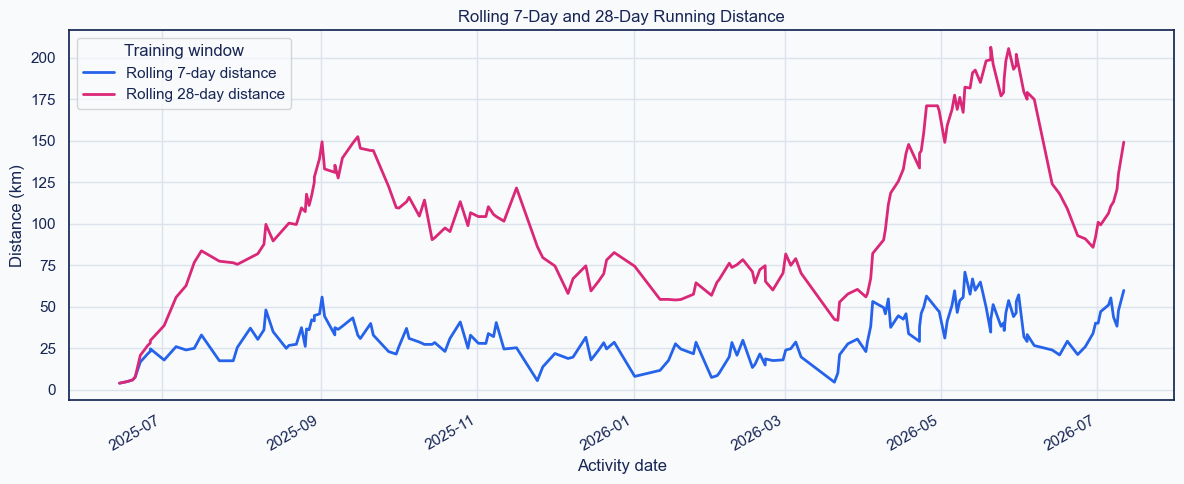

In [10]:
rolling_training = (
    featured_runs
    .sort_values("Date")
    .copy()
)

fig, axis = plt.subplots(
    figsize=(12, 5),
)

sns.lineplot(
    data=rolling_training,
    x="Date",
    y="rolling_7_day_distance_km",
    label="Rolling 7-day distance",
    color=COLORS["blue"],
    linewidth=2,
    ax=axis,
)

sns.lineplot(
    data=rolling_training,
    x="Date",
    y="rolling_28_day_distance_km",
    label="Rolling 28-day distance",
    color=COLORS["pink"],
    linewidth=2,
    ax=axis,
)

axis.set_title(
    "Rolling 7-Day and 28-Day Running Distance"
)

axis.set_xlabel("Activity date")
axis.set_ylabel("Distance (km)")
axis.legend(title="Training window")

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [11]:
rolling_training.nlargest(
    10,
    "rolling_7_day_distance_km",
)[
    [
        "Date",
        "Activity Type",
        "Distance",
        "rolling_7_day_distance_km",
        "rolling_28_day_distance_km",
    ]
]

,Date,Activity Type,Distance,rolling_7_day_distance_km,rolling_28_day_distance_km
131,2026-05-10 08:33:52,Running,15.17,70.87,182.27
133,2026-05-13 07:55:27,Running,9.18,66.79,190.94
135,2026-05-16 09:42:00,Treadmill Running,12.12,64.91,185.14
134,2026-05-14 09:25:38,Treadmill Running,8.95,59.99,192.60
168,2026-07-11 09:15:11,Running,19.0,59.87,149.22
127,2026-05-06 08:00:06,Treadmill Running,8.73,59.64,177.49
132,2026-05-12 09:16:16,Running,6.46,57.61,181.76
148,2026-05-31 08:10:16,Treadmill Running,4.08,57.19,195.03
121,2026-04-25 08:41:55,Running,16.12,56.46,171.06
32,2025-09-01 09:10:41,Running,10.13,55.86,149.41


In [12]:
rolling_training.nlargest(
    10,
    "rolling_28_day_distance_km",
)[
    [
        "Date",
        "Activity Type",
        "Distance",
        "rolling_7_day_distance_km",
        "rolling_28_day_distance_km",
    ]
]

,Date,Activity Type,Distance,rolling_7_day_distance_km,rolling_28_day_distance_km
138,2026-05-20 10:50:55,Running,7.53,42.29,206.36
144,2026-05-27 10:10:15,Running,7.34,53.76,205.54
147,2026-05-30 09:40:38,Running,6.67,53.11,202.09
137,2026-05-20 10:29:46,Running,0.68,34.76,198.83
143,2026-05-26 08:34:52,Running,10.69,46.42,198.20
136,2026-05-18 15:22:48,Running,13.01,49.72,198.15
139,2026-05-21 09:03:33,Running,9.04,51.33,196.16
146,2026-05-30 09:22:18,Running,2.34,46.44,195.42
148,2026-05-31 08:10:16,Treadmill Running,4.08,57.19,195.03
145,2026-05-29 08:09:05,Running,7.59,44.10,193.08


### Interpretation

- huge spike around April 2026 - beginning of focused HYROX 12 week program
- spike began suddenly after a period of 10 days off due to injury, then trend continued steadily upwards
- high sustained 28-day rolling volume end of April 2026 to end of June 2026
- 28-day volume increased sharply around end of April 2026 while 7-day volume stayed relatively constant

## 3. How is training volume divided between outdoor and treadmill runs?

This section compares weekly distance by activity type. The stacked
area shows both total weekly volume and how much came from outdoor
versus treadmill running.

In [13]:
runs_by_type = featured_runs.copy()

runs_by_type["week_start"] = (
    runs_by_type["Date"]
    .dt.to_period("W-SUN")
    .dt.start_time
)

weekly_distance_by_type = (
    runs_by_type
    .groupby(
        [
            "week_start",
            "Activity Type",
        ]
    )["Distance"]
    .sum()
    .unstack(
        fill_value=0
    )
    .sort_index()
)

weekly_distance_by_type.head()

Activity Type,Running,Treadmill Running
week_start,,
2025-06-09,4.0,0.0
2025-06-16,15.01,1.75
2025-06-23,8.94,0.0
2025-06-30,26.01,0.0
2025-07-07,25.02,0.0


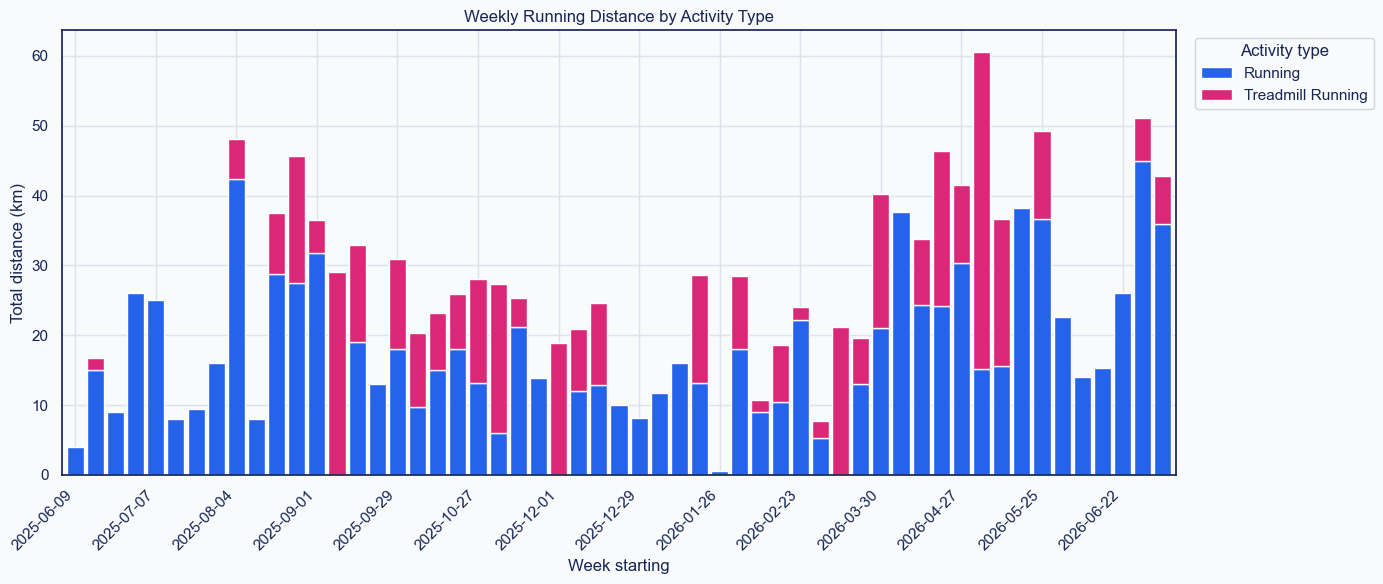

In [14]:
ACTIVITY_COLORS = {
    "Running": COLORS["blue"],
    "Treadmill Running": COLORS["pink"],
}

available_colors = [
    ACTIVITY_COLORS[column]
    for column in weekly_distance_by_type.columns
]

axis = weekly_distance_by_type.plot.bar(
    stacked=True,
    figsize=(14, 6),
    color=available_colors,
    width=0.85,
)

axis.set_title(
    "Weekly Running Distance by Activity Type"
)

axis.set_xlabel("Week starting")
axis.set_ylabel("Total distance (km)")

# Display every fourth date to keep the x-axis readable.
tick_positions = range(
    0,
    len(weekly_distance_by_type),
    4,
)

axis.set_xticks(tick_positions)

axis.set_xticklabels(
    weekly_distance_by_type
    .index
    .strftime("%Y-%m-%d")[::4],
    rotation=45,
    ha="right",
)

axis.legend(
    title="Activity type",
    loc="upper left",
    bbox_to_anchor=(1.01, 1),
)

plt.tight_layout()
plt.show()

In [15]:
activity_type_summary = (
    featured_runs
    .groupby("Activity Type")
    .agg(
        total_runs=(
            "Date",
            "size",
        ),
        total_distance_km=(
            "Distance",
            "sum",
        ),
        average_distance_km=(
            "Distance",
            "mean",
        ),
        total_moving_minutes=(
            "moving_minutes",
            "sum",
        ),
    )
)

activity_type_summary

,total_runs,total_distance_km,average_distance_km,total_moving_minutes
Activity Type,,,,
Running,107,962.12,8.991776,5285.715
Treadmill Running,62,423.47,6.830161,2474.640


In [16]:
activity_type_summary[
    "distance_percentage"
] = (
    activity_type_summary["total_distance_km"]
    / activity_type_summary["total_distance_km"].sum()
    * 100
)

activity_type_summary.round(2)

,total_runs,total_distance_km,average_distance_km,total_moving_minutes,distance_percentage
Activity Type,,,,,
Running,107,962.12,8.99,5285.72,69.44
Treadmill Running,62,423.47,6.83,2474.64,30.56


### Interpretation

- almost 70% of running done outside
- highest treadmill use around April-May 2026
- treadmill runs ~2km shorter than outdoor on average
- not enough data to determine whether treadmill use is seasonal
- highest volume weeks had greater treadmill volume than outdoor 